# Name: Kapil Kumar Sharma
# Husky CT: apl25002
# Date: 09-16-2026

**********************************************************
# Studio 1 — Data ER: PPP loans in Connecticut 🏥📊

**OPIM 5641 · Business Decision Modeling**

The SBA's Paycheck Protection Program made ~11.5 million emergency loans in 2020–21, and the
loan-level data is public. This is **real data, warts and all** — missing codes, "Unanswered"
fields, suspicious job counts. Tonight we do a **Data ER**: triage first, diagnose second,
and finish with **three findings** you can defend.

*When you have data, explore it. (Next notebook: when you don't, simulate it.)*

> **The GitHub habit (do this now):** File → **Save a copy in GitHub** → pick your `opim5641-work` repo.
> Do it again at the end of the night. Open from the course repo, work, save to *your* repo — that's the loop.

## 1 · Load the data

One CSV, already filtered to Connecticut. Every column the SBA publishes is intact — including the messy ones.

> 📖 **What do all 53 columns mean?** See the [data dictionary](https://github.com/drdave-teaching/OPIM5641-notebooks/blob/main/studio1/ppp_data_dictionary.md) — official SBA descriptions plus the watch-outs (which columns lie, which are mostly “Unanswered”, and why missing ≠ zero).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

url = 'https://raw.githubusercontent.com/k-git-uconn/Studio1-BDM-F26/main/studio1/ppp_ct.csv'

#github.com                 View/manage the file on GitHub
#raw.githubusercontent.com	Read the actual file with Python

df = pd.read_csv(url, low_memory=False)
print(df.shape)
df.head(3)

(117888, 53)


,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,LoanStatus,Term,SBAGuarantyPercentage,InitialApprovalAmount,CurrentApprovalAmount,UndisbursedAmount,FranchiseName,ServicingLenderLocationID,ServicingLenderName,ServicingLenderAddress,ServicingLenderCity,ServicingLenderState,ServicingLenderZip,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,ProjectCity,ProjectCountyName,ProjectState,ProjectZip,CD,JobsReported,NAICSCode,Race,Ethnicity,UTILITIES_PROCEED,PAYROLL_PROCEED,MORTGAGE_INTEREST_PROCEED,RENT_PROCEED,REFINANCE_EIDL_PROCEED,HEALTH_CARE_PROCEED,DEBT_INTEREST_PROCEED,BusinessType,OriginatingLenderLocationID,OriginatingLender,OriginatingLenderCity,OriginatingLenderState,Gender,Veteran,NonProfit,ForgivenessAmount,ForgivenessDate
0,3903327306,04/29/2020,156,PPP,PROPARK INC,1 Union Place,Hartford,CT,06103,08/12/2022,Paid in Full,60,100,10000000.0,10000000.0,0.0,NaN,434162,"Citizens Bank, National Association",1 Citizens Plaza,PROVIDENCE,RI,02903-1344,U,N,Y,Existing or more than 2 years old,Hartford,HARTFORD,CT,06103-1000,CT-01,500,812930.0,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,434162,"Citizens Bank, National Association",PROVIDENCE,RI,Unanswered,Unanswered,NaN,10223013.70,07/28/2022
1,4505207402,05/09/2020,156,PPP,MONROE STAFFING SERVICES LLC,6 RESEARCH DR,SHELTON,CT,06484-6228,06/22/2021,Paid in Full,24,100,10000000.0,10000000.0,0.0,NaN,81965,"Affinity Bank, National Association",3175 Hwy 278,Covington,GA,30014,U,N,N,Unanswered,SHELTON,FAIRFIELD,CT,06484-6228,CT-03,500,561311.0,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,81965,"Affinity Bank, National Association",Covington,GA,Unanswered,Unanswered,NaN,10104722.22,05/25/2021
2,5539227705,05/01/2020,156,PPP,CENVEO WORLDWIDE LIMITED,200 First Stamford Place,Stamford,CT,06902,07/16/2021,Paid in Full,24,100,10000000.0,10000000.0,0.0,NaN,9551,"Bank of America, National Association","100 N Tryon St, Ste 170",CHARLOTTE,NC,28202-4024,U,Y,Y,New Business or 2 years or less,Stamford,FAIRFIELD,CT,06902-0001,CT-04,500,322230.0,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,9551,"Bank of America, National Association",CHARLOTTE,NC,Unanswered,Unanswered,NaN,10110410.96,06/11/2021


## 2 · Triage: what have we got?

Before any analysis: how many rows and columns, what types, and **where are the holes**?

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 117888
Columns: 53


In [3]:
#for types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117888 entries, 0 to 117887
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   LoanNumber                   117888 non-null  int64  
 1   DateApproved                 117888 non-null  object 
 2   SBAOfficeCode                117888 non-null  int64  
 3   ProcessingMethod             117888 non-null  object 
 4   BorrowerName                 117888 non-null  object 
 5   BorrowerAddress              117888 non-null  object 
 6   BorrowerCity                 117888 non-null  object 
 7   BorrowerState                117888 non-null  object 
 8   BorrowerZip                  117888 non-null  object 
 9   LoanStatusDate               116775 non-null  object 
 10  LoanStatus                   117888 non-null  object 
 11  Term                         117888 non-null  int64  
 12  SBAGuarantyPercentage        117888 non-null  int64  
 13 

In [4]:
#For the holes or missing value

null_blank = df.isna().sum() + df.eq('').sum()

display(null_blank[null_blank > 0].sort_values(ascending=False))

,0
DEBT_INTEREST_PROCEED,116980
HEALTH_CARE_PROCEED,116403
FranchiseName,116194
MORTGAGE_INTEREST_PROCEED,116194
NonProfit,114373
RENT_PROCEED,114026
REFINANCE_EIDL_PROCEED,110853
UTILITIES_PROCEED,82565
ForgivenessDate,5564
ForgivenessAmount,5564


Regarding: which of these missing columns would actually matter for a business question?

Comment: NAICSCode (Industry code is important to compare loan amounts, job), ForgivenessAmount, LoanStatusDate (important to understand outcome over time)

In [5]:
result = df[
    (df['JobsReported'] == 0) |
    (df['JobsReported'].isna())
]

print("Total count of JobsReported blank or 0 is : ", result.value_counts('JobsReported'))
#21

#display(result.head(5))

Total count of JobsReported blank or 0 is :  JobsReported
0    21
Name: count, dtype: int64


Regarding: Is a missing `JobsReported` the same kind of problem as a missing `NAICSCode`?

JobsReported is number of employees. Self-reported at application. (watch out)  Zeros, blanks, and implausible values are part of the story — interrogate before you trust dollars-per-job.
NAICSCode is 6-digit NAICS industry code, (watch out) First 2 digits = sector. Missing for a chunk of rows — count what you drop.

Comment: No — they are related, but not the same kind of problem.
For JobsReported: Data quality / plausibility. Zero may be valid in the dataset, but it could also indicate an issue. Very large values should also be investigated. If the value is zero, it may create problem to calculate dollars-per-job.
For 'NAICSCode': I think, we should drop them. Missing industry information effect any calculation around it.



## 3 · Are there duplicates?

Real datasets often have near-duplicate rows. `LoanNumber` should be unique — is it?

In [6]:
#Total number of rows:
print("Total Rows count:", df.shape[0])

#Unique value to compare the if data count is same as of unique
df.nunique().sort_values(ascending=True)

Total Rows count: 117888


,0
BorrowerState,1
UndisbursedAmount,1
SBAGuarantyPercentage,1
NonProfit,1
HubzoneIndicator,2
LMIIndicator,2
RuralUrbanIndicator,2
ProcessingMethod,2
Ethnicity,3
Gender,3


Comment: LoanNumber count is equal to the total row count (i.e. 117888). And I think it should be unique for this business data, which is valid in this dataset.

Other observation:
BorrowerState → 1 unique value → potentially a data-quality issue worth investigating.
ProcessingMethod → 2 → categorical variable.
LoanStatus → 3 → potentially very useful business variable.
JobsReported → 376 → numeric variable with repeated values.
NAICSCode → 1,032 → useful industry information, but remember some values are missing.
InitialApprovalAmount → 52,445 → substantial variation, potentially important for business related question.

## 4 · Describe the money

`describe()` on the loan amounts. Then find the outliers and argue about them —
are they errors, or just the biggest employers in the state?

In [7]:
df['InitialApprovalAmount'].describe()

,InitialApprovalAmount
count,1.178880e+05
mean,8.425945e+04
std,2.764603e+05
min,0.000000e+00
25%,1.067375e+04
50%,2.083300e+04
75%,5.930000e+04
max,1.000000e+07


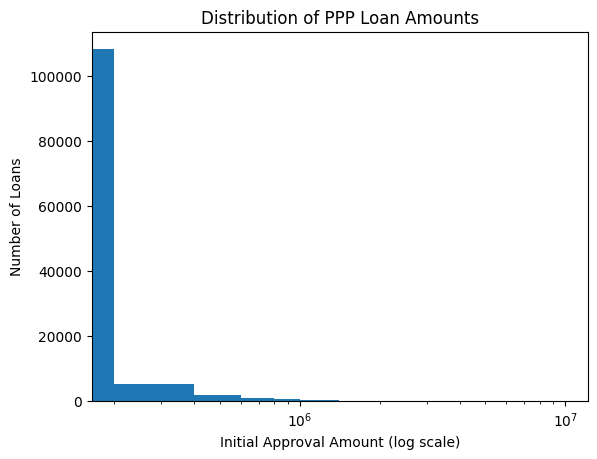

In [8]:
import matplotlib.pyplot as plt

plt.hist(df['InitialApprovalAmount'], bins=50)
plt.xscale('log')
plt.xlabel('Initial Approval Amount (log scale)')
plt.ylabel('Number of Loans')
plt.title('Distribution of PPP Loan Amounts')
plt.show()

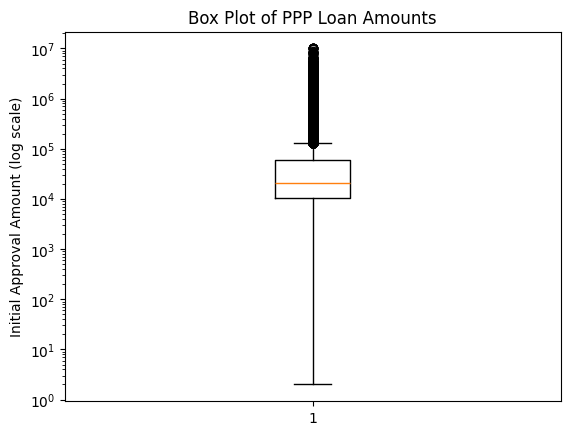

In [9]:
import matplotlib.pyplot as plt

loan_amounts = df.loc[df['InitialApprovalAmount'] > 0, 'InitialApprovalAmount']

plt.boxplot(loan_amounts)
plt.yscale('log')

plt.ylabel('Initial Approval Amount (log scale)')
plt.title('Box Plot of PPP Loan Amounts')
plt.show()

In [10]:
Q1 = df['InitialApprovalAmount'].quantile(0.25)
Q3 = df['InitialApprovalAmount'].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df[df['InitialApprovalAmount'] > upper_limit]

print("Upper outlier limit:", upper_limit)
print("Number of outliers:", len(outliers))

Upper outlier limit: 132239.375
Number of outliers: 14702


In [11]:
top_5_outliers = outliers.nlargest(5, 'InitialApprovalAmount')

display(top_5_outliers.head(2))

# display(
#     top_5_outliers[
#         ['LoanNumber', 'BorrowerName', 'InitialApprovalAmount', 'JobsReported', 'NAICSCode']
#     ]
# )

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,LoanStatus,Term,SBAGuarantyPercentage,InitialApprovalAmount,CurrentApprovalAmount,UndisbursedAmount,FranchiseName,ServicingLenderLocationID,ServicingLenderName,ServicingLenderAddress,ServicingLenderCity,ServicingLenderState,ServicingLenderZip,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,ProjectCity,ProjectCountyName,ProjectState,ProjectZip,CD,JobsReported,NAICSCode,Race,Ethnicity,UTILITIES_PROCEED,PAYROLL_PROCEED,MORTGAGE_INTEREST_PROCEED,RENT_PROCEED,REFINANCE_EIDL_PROCEED,HEALTH_CARE_PROCEED,DEBT_INTEREST_PROCEED,BusinessType,OriginatingLenderLocationID,OriginatingLender,OriginatingLenderCity,OriginatingLenderState,Gender,Veteran,NonProfit,ForgivenessAmount,ForgivenessDate
0,3903327306,04/29/2020,156,PPP,PROPARK INC,1 Union Place,Hartford,CT,06103,08/12/2022,Paid in Full,60,100,10000000.0,10000000.0,0.0,NaN,434162,"Citizens Bank, National Association",1 Citizens Plaza,PROVIDENCE,RI,02903-1344,U,N,Y,Existing or more than 2 years old,Hartford,HARTFORD,CT,06103-1000,CT-01,500,812930.0,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,434162,"Citizens Bank, National Association",PROVIDENCE,RI,Unanswered,Unanswered,NaN,10223013.70,07/28/2022
1,4505207402,05/09/2020,156,PPP,MONROE STAFFING SERVICES LLC,6 RESEARCH DR,SHELTON,CT,06484-6228,06/22/2021,Paid in Full,24,100,10000000.0,10000000.0,0.0,NaN,81965,"Affinity Bank, National Association",3175 Hwy 278,Covington,GA,30014,U,N,N,Unanswered,SHELTON,FAIRFIELD,CT,06484-6228,CT-03,500,561311.0,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,81965,"Affinity Bank, National Association",Covington,GA,Unanswered,Unanswered,NaN,10104722.22,05/25/2021


Comment: We have 14702 outliers and the upper outer limit for outlier is calculated as '132239.375'.
They are extreme loan amount but they should not automatically be treated as errors. In fact, the other fields provide evidence that they may represent legitimate large employers.

Regarding **Mean vs median time** (this is your Math Check muscle): compute both for `InitialApprovalAmount`.
Which is bigger, and what does that gap tell you about who got PPP money?

In [12]:
mean = df['InitialApprovalAmount'].mean()
median = df['InitialApprovalAmount'].median()

print(f"Mean: ${mean:,.2f}")
print(f"Median: ${median:,.2f}")

Mean: $84,259.45
Median: $20,833.00


Comment: From InitialApprovalAmount describe() code above and the output data, it seems the gap in mean and median is:

Mean = 84,259
Median = 20,833
Gap = 63,426

The mean is much higher than the median. This tells us the loan data is strongly right-skewed: most loans are relatively small, while a smaller number of very large loans pull the mean upward.

Regarding Which is bigger, and what does that gap tell you about who got PPP money?

The median loan of about $20,833 suggests that a typical PPP borrower received a relatively small loan, while the much higher mean of about 84,259 shows that a smaller group of borrowers received substantially larger amounts. This indicates that PPP funds were distributed across many smaller borrowers as well as a smaller number of large-dollar loans.

#### Reading the log histogram (once you've built it)

- `np.log` is the **natural log (base e)**. The x-axis above is ln(dollars): 10 ≈ 22k, 12 ≈ 163k, 14 ≈ 1.2M — and every **+2.3** on the axis is another **×10** in dollars.
- **Why it's easier to read:** raw loan amounts span five orders of magnitude (hundreds to 10M), so a plain histogram is one giant bar plus an invisible tail. The log turns *ratios* into equal *distances* — it compresses the huge tail and stretches the crowded low end. What's left is roughly bell-shaped: money data is classically **log-normal**.
- **Tie to `.describe()`:** the **median 20,833** → ln ≈ 9.9 lands exactly on the peak (log keeps order, so the middle value stays the middle value). The **mean 84,260** → ln ≈ 11.3 sits well right of the peak — dragged by the multi-million-dollar loans. The unreadable raw histogram, the mean ≫ median gap, and the bell-in-logs are **the same fact three ways**: this data is right-skewed.
- The `> 0` filter is the guard rail: ln(0) = −∞ and the log of a negative number is undefined.
- **Try it:** re-plot with `np.log10` instead — then the ticks read directly as dollars (3 = 1k, 4 = 10k, 5 = 100k, 6 = 1M), and add `plt.axvline` at the median and the mean to *see* the skew.

Recreating with natural log (np.log, base e)

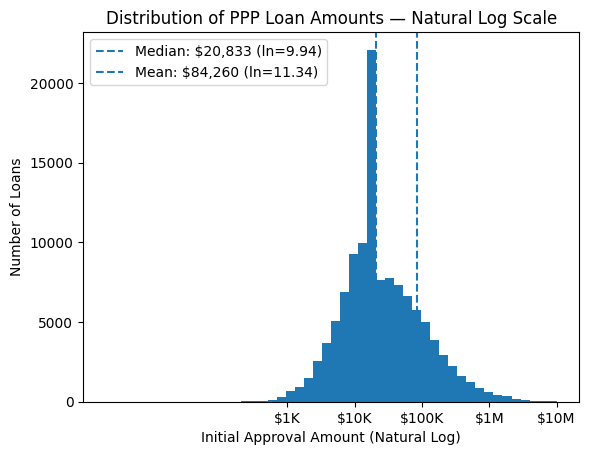

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Remove zero values because ln(0) is undefined
loan_amounts = df.loc[df['InitialApprovalAmount'] > 0, 'InitialApprovalAmount']

# Calculate mean and median
mean = loan_amounts.mean()
median = loan_amounts.median()

# Natural log transformation
log_amounts = np.log(loan_amounts)

# Plot histogram
plt.hist(log_amounts, bins=50)

# Add median and mean lines
plt.axvline(
    np.log(median),
    linestyle='--',
    label=f'Median: ${median:,.0f} (ln={np.log(median):.2f})'
)

plt.axvline(
    np.log(mean),
    linestyle='--',
    label=f'Mean: ${mean:,.0f} (ln={np.log(mean):.2f})'
)

# Natural-log x-axis ticks
tick_values = [1_000, 10_000, 100_000, 1_000_000, 10_000_000]
tick_positions = np.log(tick_values)

plt.xticks(
    tick_positions,
    ['$1K', '$10K', '$100K', '$1M', '$10M']
)

plt.xlabel('Initial Approval Amount (Natural Log)')
plt.ylabel('Number of Loans')
plt.title('Distribution of PPP Loan Amounts — Natural Log Scale')
plt.legend()
plt.show()

Regarding: Try it: re-plot with np.log10 instead — then the ticks read directly as dollars (3 = 1k, 4 = 10k, 5 = 100k, 6 = 1M), and add plt.axvline at the median and the mean to see the skew.

Transformation used:
//Log transform
log_amounts = np.log10(loan_amounts)

Also for the ticks:
//Dollar-style tick labels
plt.xticks(
    [3, 4, 5, 6, 7],
    ['$1K', '$10K', '$100K', '$1M', '$10M']
)

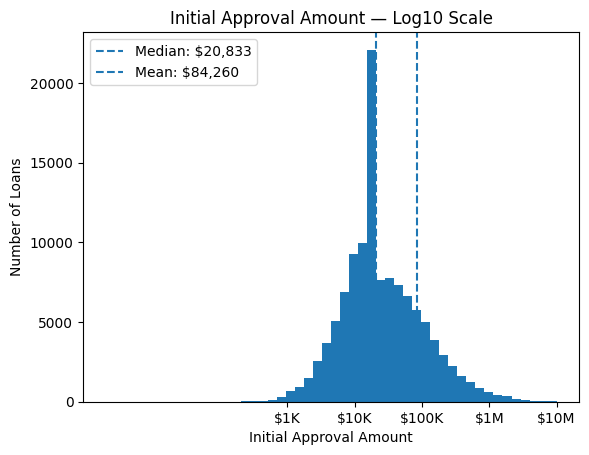

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Remove zero values because log10(0) is undefined
loan_amounts = df[df['InitialApprovalAmount'] > 0]['InitialApprovalAmount']

# Calculate mean and median
mean = loan_amounts.mean()
median = loan_amounts.median()

# Log transform
log_amounts = np.log10(loan_amounts)

# Histogram
plt.hist(log_amounts, bins=50)

# Mean and median lines
plt.axvline(np.log10(median), linestyle='--', label=f'Median: ${median:,.0f}')
plt.axvline(np.log10(mean), linestyle='--', label=f'Mean: ${mean:,.0f}')

# Dollar-style tick labels
plt.xticks(
    [3, 4, 5, 6, 7],
    ['$1K', '$10K', '$100K', '$1M', '$10M']
)

plt.xlabel('Initial Approval Amount')
plt.ylabel('Number of Loans')
plt.title('Initial Approval Amount — Log10 Scale')
plt.legend()

plt.show()

## 5 · Which industries got the money?

`NAICSCode` is a 6-digit industry code — the first 2 digits give the sector. Watch how many rows we lose to missing codes.

In [15]:
#Execution 1
df['NAICSCode'].isna().sum()

np.int64(1535)

So missing NAICS code rows are: 1535. We can consider imputation technique for  the missing values, since these rowss are only a small portion of the data.

In [16]:
#Execution 2
df['NAICSCode'] = df['NAICSCode'].astype('Int64')
df['Sector'] = df['NAICSCode'].astype('string').str[:2]

display(df[['NAICSCode', 'Sector']].head(5))

,NAICSCode,Sector
0,812930,81
1,561311,56
2,322230,32
3,561720,56
4,541110,54


* Exection 1: Count of total blank NAICSCode rows is: 1535
* Execution 2: NAICSCode datatype is 'float64' and not null. Convert it to int and then extract the first two digit that gives us the sector

In [26]:
sector_frequency = df['Sector'].value_counts().sort_index()
display(sector_frequency.head(5))

,count
Sector,
11,736
21,163
22,177
23,13929
31,1079


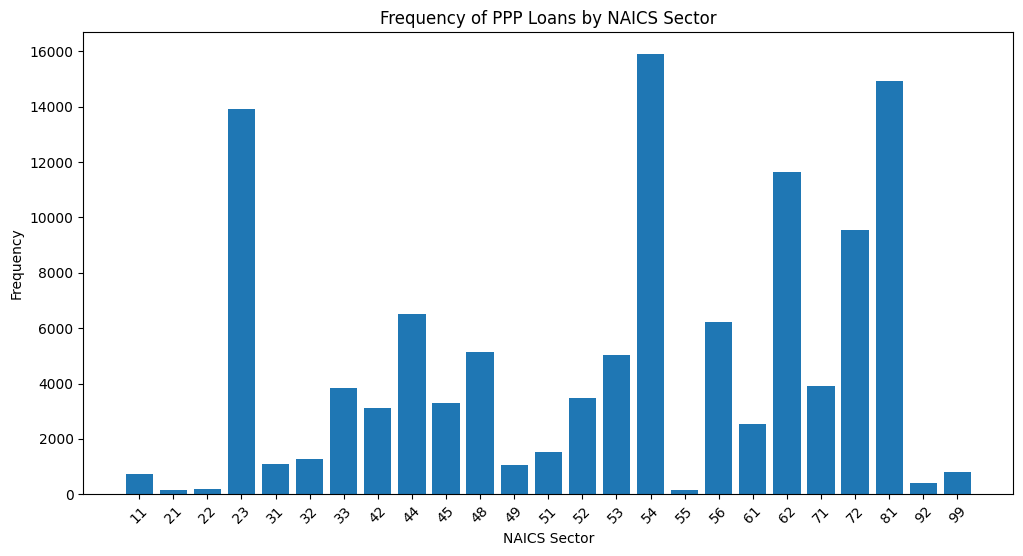

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(sector_frequency.index, sector_frequency.values)

plt.xlabel('NAICS Sector')
plt.ylabel('Frequency')
plt.title('Frequency of PPP Loans by NAICS Sector')

plt.xticks(rotation=45)
plt.show()

Comment: From frequency chart, PPP loans are mostly distributed amount following major sectors.
1. 23: Construction
2. 54: Professional, Scientific and Technical Services
3. 62: Health Care, Social Assistance
4. 72: Accomodation and Food Services
5. 81: Other Services (except Public Admin) sector for business that provide specific personal, repair and community services not found in other industries.

Source of info: https://www.naics.com/six-digit-naics/?code=81

## 6 · Where in Connecticut?

Top cities by loan count — and watch for the data dirt (same city spelled multiple ways?).

First lets group project city by checking the data dirt for spelled multiple ways

In [35]:
ct_df = df[df['ProjectState'] == 'CT'].copy()

top_cities = ct_df['ProjectCity'].value_counts().head(10)

ct_df['City_Clean'] = (
    ct_df['ProjectCity']
    .astype('string')
    .str.upper()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[.,]', '', regex=True)
)

'City_Clean' in ct_df dataframe now contain all the correct city name mapped to the actual city, i.e. 'ProjectCity'

In [36]:
cities = sorted(ct_df['City_Clean'].dropna().unique())

for city in cities:
    print(city)

 BRIDGEPORT
06040
06108
06111
06410
06460
06468
06511
06614
06704
06705
06790
06811
07410
11 KELLY CREST RD
143 ALDER STREER
1460 MERIDEN WATERBURY TURNPIKE
158 MANOR AVE UNIT-1
175 CAPITAL BLVD ROCKY HILL
20 RIDGE RD CI
214 AMITY ROAD
220 HILLSIDE AVE
3 ISSAC STREET
30
336 W PUTNAM AVENUE
385 BROAD ST
44 SOUTH MAIN STREET
500 COLD SPRING RD
510 LONG HILL RD
56 DENISON AVE
57 BUCKINHAM ST
7 KENT GREEN BOULEVARD
71 ASYLUM ST
77 E MAIN ST
770 CAMPBELL AVENEU
ABINGTON
AMSTON
ANDOVER
ANSONIA
ASHFORD
AVON
BALTIC
BANTAM
BARKHAMSTEAD
BARKHAMSTED
BEACON FALLS
BEACONFALLS
BERIN
BERLIN
BERLING
BETHANY
BETHEL
BETHEL CT
BETHLEHEM
BLACK ROCK
BLOOMFIELD
BOLTON
BOTON
BOTSFORD
BOZRAH
BRANFORD
BRANFORD CT
BRAOD BROOK
BRDGEPORT
BRIDEGEWATER
BRIDGEFIELD
BRIDGEPORPT
BRIDGEPORT
BRIDGEWATER
BRISSTOL
BRISTOL
BRISTOL CT
BRISTOLL
BROAD BROO
BROAD BROOK
BROADBROOK DRIVE
BROOKFIELD
BROOKLYN
BUILDING
BURLINGTON
BURLINTON
CANAAN
CANTERBURY
CANTON
CANTON CENTER
CENTERBROOK
CENTRAL VILLAGE
CHAPLIN
CHESHIRE
CHESIRE
C

To list the potentially similar/misspelled city names, will use approach ** fuzzy matching**

In [37]:
from difflib import get_close_matches

cities = sorted(ct_df['City_Clean'].dropna().unique())

possible_matches = []

for city in cities:
    matches = get_close_matches(
        city,
        [c for c in cities if c != city],
        n=3,
        cutoff=0.85
    )

    for match in matches:
        possible_matches.append((city, match))

display(possible_matches)

[(' BRIDGEPORT', 'BRIDGEPORT'),
 (' BRIDGEPORT', 'BRIDGEPORPT'),
 (' BRIDGEPORT', 'BRDGEPORT'),
 ('ANDOVER', 'HANOVER'),
 ('BARKHAMSTEAD', 'BARKHAMSTED'),
 ('BARKHAMSTED', 'BARKHAMSTEAD'),
 ('BEACON FALLS', 'BEACONFALLS'),
 ('BEACONFALLS', 'BEACON FALLS'),
 ('BERIN', 'BERLIN'),
 ('BERLIN', 'BERLING'),
 ('BERLIN', 'BERIN'),
 ('BERLING', 'BERLIN'),
 ('BOLTON', 'BOTON'),
 ('BOTON', 'BOLTON'),
 ('BRANFORD', 'N BRANFORD'),
 ('BRAOD BROOK', 'BROAD BROOK'),
 ('BRAOD BROOK', 'BROAD BROO'),
 ('BRDGEPORT', 'BRIDGEPORT'),
 ('BRDGEPORT', 'BRIDGEPORPT'),
 ('BRDGEPORT', ' BRIDGEPORT'),
 ('BRIDEGEWATER', 'BRIDGEWATER'),
 ('BRIDGEFIELD', 'RIDGEFIELD'),
 ('BRIDGEFIELD', 'RIADGEFIELD'),
 ('BRIDGEFIELD', 'RIDGEFIED'),
 ('BRIDGEPORPT', 'BRIDGEPORT'),
 ('BRIDGEPORPT', ' BRIDGEPORT'),
 ('BRIDGEPORPT', 'BRDGEPORT'),
 ('BRIDGEPORT', 'BRIDGEPORPT'),
 ('BRIDGEPORT', ' BRIDGEPORT'),
 ('BRIDGEPORT', 'BRDGEPORT'),
 ('BRIDGEWATER', 'BRIDEGEWATER'),
 ('BRISSTOL', 'BRISTOL'),
 ('BRISSTOL', 'BRISTOLL'),
 ('BRISTOL', '

For top cities by loan count (Number of loans, NOT the total amount of loan per sector).
We can count the number of cities (Clean city) in the ct_df dataframe.

In [42]:
# For data dirt
city_counts = ct_df['City_Clean'].value_counts()

display(city_counts.head(10))

,count
City_Clean,
STAMFORD,6387
NORWALK,4127
BRIDGEPORT,4120
NEW HAVEN,3765
HARTFORD,3389
WATERBURY,2946
FAIRFIELD,2662
DANBURY,2659
GREENWICH,2335


## 7 · The dollars-per-job question

PPP was meant to protect paychecks. So: **dollars per job reported**. What do you find at the extremes —
and do you believe the `JobsReported` column?

To calculate dollar per job reported, will use formula (approved loan amount / jobs reported).

First check both column values, datatype and missing value fix.

In [45]:
print("JobsReported = 0:", (df['JobsReported'] == 0).sum())
print("JobsReported missing:", df['JobsReported'].isna().sum())
print("JobsReported negative:", (df['JobsReported'] < 0).sum())
print("Maximum JobsReported:", df['JobsReported'].max())

JobsReported = 0: 21
JobsReported missing: 0
JobsReported negative: 0
Maximum JobsReported: 500


* JobsReported = 0 cannot be used to calculate dollars/job and should be treated separately.
* Extremely large JobsReported values should be investigated rather than automatically removed.
* JobsReported is a self-reported field, so the dataset alone cannot prove that every employment figure is accurate.

In [46]:
df['DollarsPerJob'] = (
    df['InitialApprovalAmount'] /
    df['JobsReported'].replace(0, np.nan)
)

In [47]:
df['DollarsPerJob'].describe()

,DollarsPerJob
count,1.178670e+05
mean,1.077494e+04
std,1.086541e+04
min,0.000000e+00
25%,5.000000e+03
50%,9.264000e+03
75%,1.511200e+04
max,1.295640e+06


In [48]:
display(
    df.nlargest(10, 'JobsReported')[
        ['LoanNumber', 'BorrowerName',
         'InitialApprovalAmount', 'JobsReported']
    ]
)

,LoanNumber,BorrowerName,InitialApprovalAmount,JobsReported
0,3903327306,PROPARK INC,10000000.0,500
1,4505207402,MONROE STAFFING SERVICES LLC,10000000.0,500
2,5539227705,CENVEO WORLDWIDE LIMITED,10000000.0,500
3,5630057006,SERVICE MANAGEMENT GROUP,10000000.0,500
7,4798897206,"STARLING PHYSICIANS, P.C. & SUBSIDIARIES",8883100.0,500
11,4930797100,"AFFINECO, LLC",8357000.0,500
16,3613298809,ABILITY BEYOND DISABILITY INC.,7634700.0,500
18,3368847306,"CONNECTICUT ORTHOPAEDIC SPECIALISTS, P.C.",7117097.9,500
19,8381377010,HAMILTON CONNECTIONS INC,6800900.0,500
24,9600147006,NCL ACQUISITION CORP.,6391860.0,500


Observation:
Very high dollars/job could result from a large loan combined with a surprisingly small reported workforce.
Very low dollars/job could result from many reported employees receiving a relatively small loan.

Comment: The dollars-per-job analysis helps evaluate whether the reported employment figures are relative to the loan amounts.
* Regarding Extreme values: it should be investigated because they may reflect either unusually large or small loans or potentially questionable JobsReported values. I would not automatically remove these observations.
* Regarding JobsReported column: Since JobsReported is like self-reported, it should be treated as a useful but imperfect variable, and extreme or zero values should be examined before using it in a predictive model.


## 8 · Your three findings 📝

With your partner, write **three findings** below. Each one = **one plot or one table + two sentences**
(what you see, and why a decision-maker should care). This is the exact shape Assignment 1 grades.

Then: File → **Save a copy in GitHub** → your `opim5641-work` repo.

### Finding 1

1. Loan taken by which city 'BorrowerCity' in 'Connecticut' and the amount of loan defaulter. Check loan status

In [67]:
# standardize BorrowerCity
ct_df['BorrowerCity_Clean'] = (
    ct_df['BorrowerCity']
    .astype('string')
    .str.strip()
    .str.upper()
)

In [68]:
display(ct_df['LoanStatus'].value_counts())

,count
LoanStatus,
Paid in Full,112882
Charged Off,3893
Exemption 4,1113


"Exemption 4" means the loan is disbursed but not yet Paid in Full or Charged Off (FOIA redaction, not a real status)

In [69]:
charged_off = ct_df[ct_df['LoanStatus'] == 'Charged Off'].copy()

In [71]:
default_by_city = (
    charged_off
    .groupby('BorrowerCity_Clean')
    .agg(
        LoanCount=('LoanNumber', 'count'),
        TotalLoanAmount=('InitialApprovalAmount', 'sum')
    )
    .sort_values('LoanCount', ascending=False)
)

display(default_by_city.head(10))

,LoanCount,TotalLoanAmount
BorrowerCity_Clean,,
BRIDGEPORT,380,7666135.83
NEW HAVEN,285,11033310.61
HARTFORD,268,7649106.18
WATERBURY,225,6185148.63
STAMFORD,214,6787853.04
NORWALK,121,3774558.94
HAMDEN,95,1910650.25
NEW BRITAIN,93,1583812.97
DANBURY,87,1329071.67


The above table will indicates, which Connecticut borrower cities have Charged Off loans, how many are there, and what is the total initial loan amount?

Finding: After standardizing city names, Bridgeport, Hartford, and New Haven have the highest numbers of Charged Off PPP loans among Connecticut cities. Standardizing the city names ensures that variations such as New Haven and NEW HAVEN are treated as the same city and prevents the results from being split across duplicate categories.

### Finding 2

2. which ServicingLendingBank issued maximum loan and in which sector

In [72]:
lender_counts = (
    df['ServicingLenderName']
    .value_counts()
)

display(lender_counts.head(10))

,count
ServicingLenderName,
Manufacturers and Traders Trust Company,15513
Webster Bank National Association,13607
"Bank of America, National Association",9498
"TD Bank, National Association",5972
Liberty Bank,5784
Cross River Bank,3981
"JPMorgan Chase Bank, National Association",3916
"Citizens Bank, National Association",3470
KeyBank National Association,3370


In [73]:
top_lender = lender_counts.index[0]

print("Top Servicing Lender:", top_lender)

Top Servicing Lender: Manufacturers and Traders Trust Company


So the top Servicing Lender: Manufacturers and Traders Trust Company and now lets calculate in which top 5 sector it landed money

In [79]:
top_lender_df = df[
    df['ServicingLenderName'] == 'Manufacturers and Traders Trust Company'
].copy()

In [80]:
top_lender_sector = (
    top_lender_df
    .groupby('Sector')
    .size()
    .sort_values(ascending=False)
)

display(top_lender_sector.head(5))

,0
Sector,
54,2225
23,2210
81,1862
62,1506
72,1256


Finding: The top lender that issues money is by servicing company: 'Manufacturers and Traders Trust Company' and top 5 sector in which it money is: 54 (Professional, Scientific, and Technical Services sector), 23(Construction), 81(Other Services (except Public Administration)), 62(Health Care and Social Assistance sector) and 72(Accommodation and Food Services industry)

### Finding 3

3. ForgivenessAmount, which sector have not forigiven loan and for what sector forgiven is the most. based on BusinessType

In [81]:
# A missing ForgivenessAmount means there is no recorded forgiveness amount in the dataset.
# Don't automatically call it "not forgiven" without qualification; call it "no recorded forgiveness amount."

df['Forgiven'] = df['ForgivenessAmount'].notna()

In [85]:
df.head(2)

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,LoanStatus,Term,SBAGuarantyPercentage,InitialApprovalAmount,CurrentApprovalAmount,UndisbursedAmount,FranchiseName,ServicingLenderLocationID,ServicingLenderName,ServicingLenderAddress,ServicingLenderCity,ServicingLenderState,ServicingLenderZip,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,ProjectCity,ProjectCountyName,ProjectState,ProjectZip,CD,JobsReported,NAICSCode,Race,Ethnicity,UTILITIES_PROCEED,PAYROLL_PROCEED,MORTGAGE_INTEREST_PROCEED,RENT_PROCEED,REFINANCE_EIDL_PROCEED,HEALTH_CARE_PROCEED,DEBT_INTEREST_PROCEED,BusinessType,OriginatingLenderLocationID,OriginatingLender,OriginatingLenderCity,OriginatingLenderState,Gender,Veteran,NonProfit,ForgivenessAmount,ForgivenessDate,Sector,DollarsPerJob,Forgiven
0,3903327306,04/29/2020,156,PPP,PROPARK INC,1 Union Place,Hartford,CT,06103,08/12/2022,Paid in Full,60,100,10000000.0,10000000.0,0.0,NaN,434162,"Citizens Bank, National Association",1 Citizens Plaza,PROVIDENCE,RI,02903-1344,U,N,Y,Existing or more than 2 years old,Hartford,HARTFORD,CT,06103-1000,CT-01,500,812930,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,434162,"Citizens Bank, National Association",PROVIDENCE,RI,Unanswered,Unanswered,NaN,10223013.70,07/28/2022,81,20000.0,True
1,4505207402,05/09/2020,156,PPP,MONROE STAFFING SERVICES LLC,6 RESEARCH DR,SHELTON,CT,06484-6228,06/22/2021,Paid in Full,24,100,10000000.0,10000000.0,0.0,NaN,81965,"Affinity Bank, National Association",3175 Hwy 278,Covington,GA,30014,U,N,N,Unanswered,SHELTON,FAIRFIELD,CT,06484-6228,CT-03,500,561311,Unanswered,Unknown/NotStated,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,Corporation,81965,"Affinity Bank, National Association",Covington,GA,Unanswered,Unanswered,NaN,10104722.22,05/25/2021,56,20000.0,True


In [89]:
# Forgiveness by sector
sector_forgiveness = (
    df.groupby('Sector')
      .agg(
          TotalLoans=('LoanNumber', 'count'),
          ForgivenLoans=('Forgiven', 'sum'),
          TotalForgivenessAmount=('ForgivenessAmount', 'sum')
      )
      .reset_index()
)

display(
    sector_forgiveness.sort_values(
        'ForgivenLoans',
        ascending=False
    ).head(10)
)

,Sector,TotalLoans,ForgivenLoans,TotalForgivenessAmount
15,54,15897,15418,1.162120e+09
22,81,14922,13951,6.660495e+08
3,23,13929,13327,1.165676e+09
19,62,11634,11284,1.439004e+09
21,72,9562,9067,9.078538e+08
8,44,6496,6200,5.420121e+08
17,56,6218,5871,4.453946e+08
14,53,5019,4800,2.226413e+08
10,48,5129,4586,2.177032e+08
6,33,3849,3771,8.838499e+08


Finding: The analysis shows that the highest number of forgiven PPP loans is concentrated in five NAICS sectors: Sector 54 – Professional, Scientific, and Technical Services, Sector 81 – Other Services (except Public Administration), Sector 23 – Construction, Sector 62 – Health Care and Social Assistance, and Sector 72 – Accommodation and Food Services. These sectors represent the areas with the greatest number of recorded loan forgiveness cases in the dataset.